# SuperKart — Automated MLOps Sales Forecasting Pipeline

**Role:** MLOps Engineer
**Goal:** build an automated, CI/CD-driven pipeline that registers data and
models on the Hugging Face Hub, trains and tunes a sales-forecasting model,
and deploys it as a live Streamlit app — so different business verticals can
get continuously refreshed, reliable revenue forecasts with minimal manual
work.

This notebook is the single, run-from-top-to-bottom record of every rubric
section: data registration, data preparation, model training & registration,
deployment, the GitHub Actions CI/CD workflow, and the final output
evaluation / insights.

**Repo layout** (see `README.md` for the full description):

```
superkart-mlops/
├── data/{raw,processed}/
├── notebooks/SuperKart_MLOps_Pipeline.ipynb   <- this file
├── src/{config,utils,data_prep,train}.py
├── deployment/{app.py,Dockerfile,requirements.txt,hosting.py}
└── .github/workflows/pipeline.yml
```

> **Note on execution environment.** This notebook calls the exact same
> functions used by the automated pipeline (`src/data_prep.py`,
> `src/train.py`, `deployment/hosting.py`). Those functions detect whether a
> Hugging Face token (`HF_TOKEN`) is available: **with** a token (e.g. when
> run in Colab, locally, or inside the GitHub Actions workflow) they
> register the data, model, and Space on the Hugging Face Hub for real;
> **without** one they still run every cleaning / training / evaluation step
> on real data, and simply log that the Hub push was skipped. That is the
> state you'll see below — the Hugging Face and GitHub links are added once
> the token/repo are in place (see the **Output Evaluation** section).

In [1]:
# ---- Setup ----
# This notebook lives in notebooks/, but is meant to be run with the
# project's master folder (this repo) as the effective working directory,
# matching how src/data_prep.py, src/train.py, and deployment/hosting.py
# are run by both a developer and the GitHub Actions pipeline.
import sys, os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import config, utils, data_prep
from src import train as train_module

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("HF_USERNAME:", config.HF_USERNAME)
print("HF token configured:", bool(config.HF_TOKEN))
print("Dataset repo:", config.DATASET_REPO_ID)
print("Model repo:  ", config.MODEL_REPO_ID)
print("Space repo:  ", config.SPACE_REPO_ID)

HF_USERNAME: your-hf-username
HF token configured: False
Dataset repo: your-hf-username/superkart-sales-data
Model repo:   your-hf-username/superkart-sales-model
Space repo:   your-hf-username/superkart-sales-app


## 1. Data Registration

Rubric: *create a master folder + `data` subfolder, and register the raw
dataset on the Hugging Face dataset space.*

The master folder is this repository, `superkart-mlops/`, with the raw CSV
under `data/raw/SuperKart.csv`. `src/data_prep.register_raw_data()` creates
(or reuses) the Hugging Face dataset repo `config.DATASET_REPO_ID` and
uploads the raw file to it.

In [2]:
print("Master folder:", os.getcwd())
for root, dirs, files in os.walk("."):
    dirs[:] = [d for d in dirs if d not in {".git", "__pycache__", ".ipynb_checkpoints"}]
    level = root.replace(".", "", 1).count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root) or '.'}/")
    for f in sorted(files):
        print(f"{indent}  {f}")

Master folder: /home/claude/superkart-mlops
./
  .gitignore
  README.md
  requirements.txt
  src/
    __init__.py
    config.py
    data_prep.py
    train.py
    utils.py
  .github/
    workflows/
      pipeline.yml
  notebooks/
    SuperKart_MLOps_Pipeline.ipynb
  data/
    raw/
      SuperKart.csv
    processed/
  deployment/
    Dockerfile
    __init__.py
    app.py
    hosting.py
    requirements.txt


In [3]:
data_prep.register_raw_data()

[data_prep] HF not configured -> skipping raw data registration.


## 2. Data Preparation

Rubric: *load the dataset directly from the Hugging Face dataset space,
clean it and remove unnecessary columns, split into train/test, save
locally, and upload the resulting train/test sets back to the dataset
space.*

In [4]:
raw_df = data_prep.load_raw_data()
print(raw_df.shape)
raw_df.head()

[data_prep] Loaded raw data from local file: data/raw/SuperKart.csv
(8763, 12)


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [5]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   str    
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   str    
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   str    
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   str    
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   str    
 9   Store_Location_City_Type   8763 non-null   str    
 10  Store_Type                 8763 non-null   str    
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 821.7 KB


In [6]:
raw_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,8763,8763,FD6114,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,8763.0,NaN,NaN,NaN,12.653792,2.21732,4.0,11.15,12.66,14.18,22.0
Product_Sugar_Content,8763,4,Low Sugar,4885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,8763.0,NaN,NaN,NaN,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_Type,8763,16,Fruits and Vegetables,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,8763.0,NaN,NaN,NaN,147.032539,30.69411,31.0,126.16,146.74,167.585,266.0
Store_Id,8763,4,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,8763.0,NaN,NaN,NaN,2002.032751,8.388381,1987.0,1998.0,2009.0,2009.0,2009.0
Store_Size,8763,3,Medium,6025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,8763,3,Tier 2,6262,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Missing values check
raw_df.isna().sum().to_frame("missing_values")

,missing_values
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


In [8]:
# Data-quality issue: inconsistent labels in Product_Sugar_Content
print(raw_df["Product_Sugar_Content"].value_counts())

Product_Sugar_Content
Low Sugar    4885
Regular      2251
No Sugar     1519
reg           108
Name: count, dtype: int64


**Observation:** `Product_Sugar_Content` contains a stray value `"reg"` that
clearly means `"Regular"`. `Product_Id` is a unique identifier per row and
`Store_Id` only re-expresses attributes we already have as separate columns
(`Store_Size`, `Store_Location_City_Type`, `Store_Type`,
`Store_Establishment_Year`) — neither identifier carries independent
predictive signal, so both are dropped as *unnecessary columns* during
cleaning.

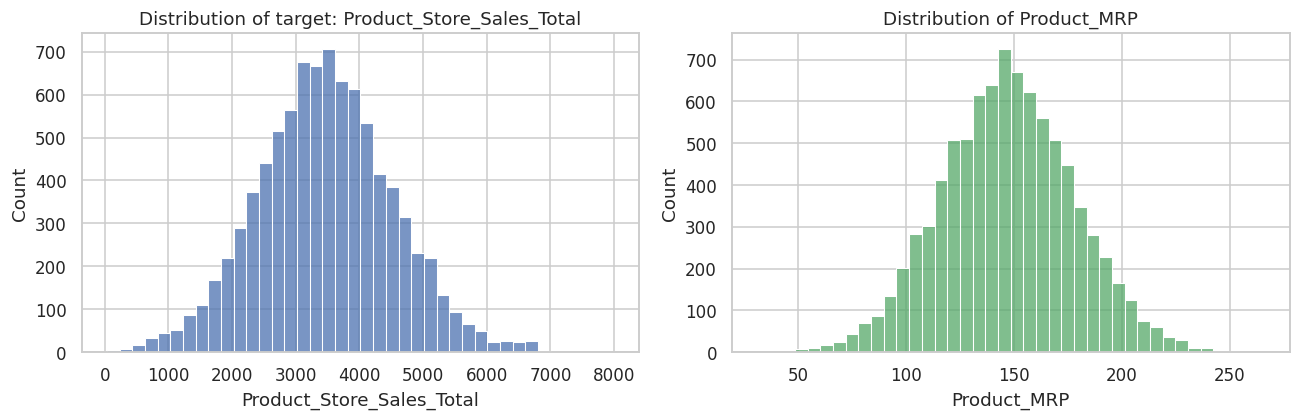

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(raw_df["Product_Store_Sales_Total"], bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of target: Product_Store_Sales_Total")
sns.histplot(raw_df["Product_MRP"], bins=40, ax=axes[1], color="#55A868")
axes[1].set_title("Distribution of Product_MRP")
plt.tight_layout()
plt.show()

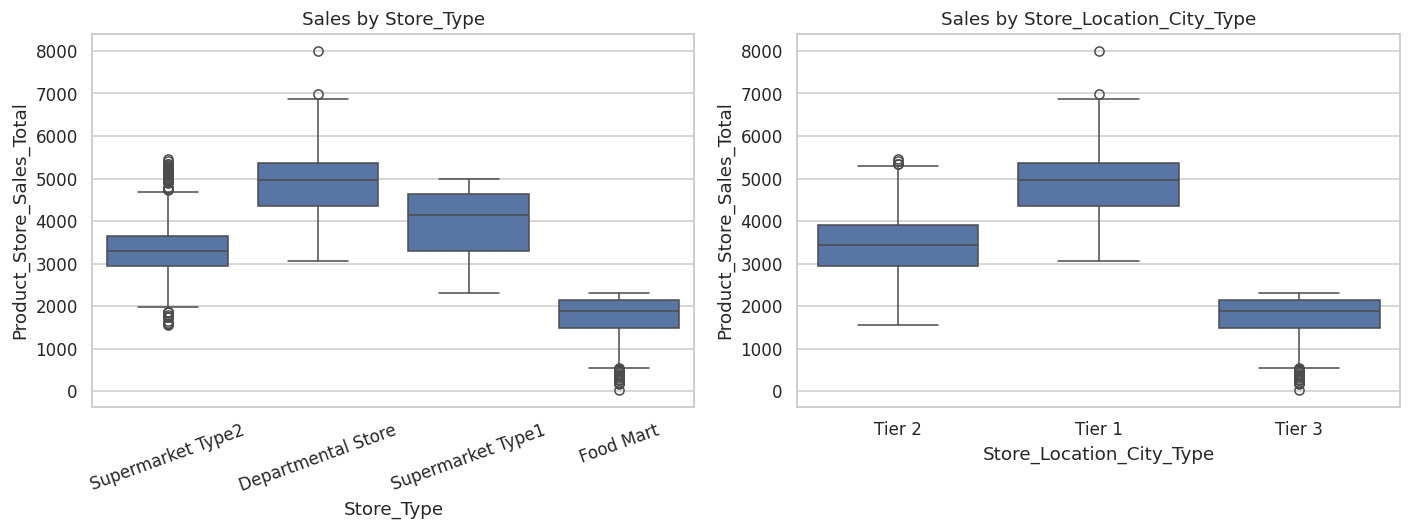

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=raw_df, x="Store_Type", y="Product_Store_Sales_Total", ax=axes[0])
axes[0].set_title("Sales by Store_Type")
axes[0].tick_params(axis="x", rotation=20)
sns.boxplot(data=raw_df, x="Store_Location_City_Type", y="Product_Store_Sales_Total", ax=axes[1])
axes[1].set_title("Sales by Store_Location_City_Type")
plt.tight_layout()
plt.show()

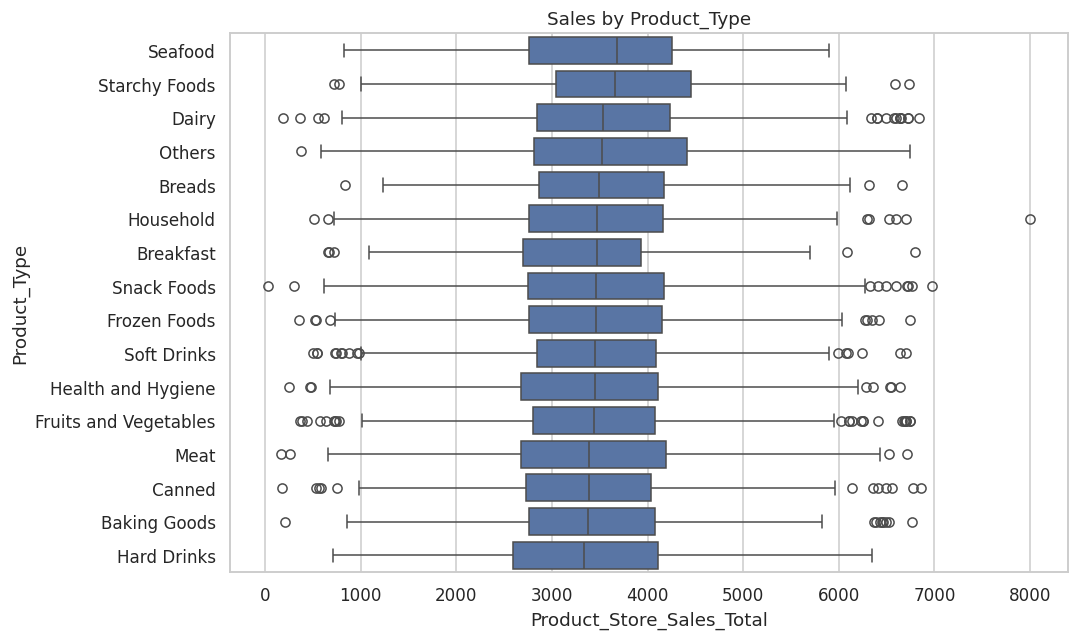

In [11]:
plt.figure(figsize=(10, 6))
order = raw_df.groupby("Product_Type")["Product_Store_Sales_Total"].median().sort_values(ascending=False).index
sns.boxplot(data=raw_df, x="Product_Store_Sales_Total", y="Product_Type", order=order)
plt.title("Sales by Product_Type")
plt.tight_layout()
plt.show()

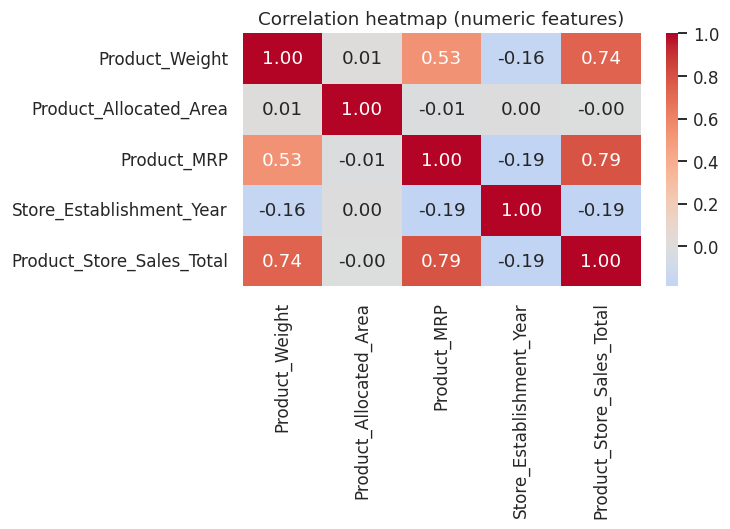

In [12]:
numeric_cols = ["Product_Weight", "Product_Allocated_Area", "Product_MRP",
                "Store_Establishment_Year", "Product_Store_Sales_Total"]
plt.figure(figsize=(7, 5))
sns.heatmap(raw_df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap (numeric features)")
plt.tight_layout()
plt.show()

**Insights from EDA:**
- `Product_MRP` is the strongest linear driver of sales (positive
  correlation) — higher-priced products generate more revenue per sale.
- `Store_Type` and `Store_Location_City_Type` both show clear separation in
  the median and spread of sales, so they carry real predictive signal for
  a tree-based model even though their linear correlation isn't captured by
  the heatmap (they're categorical).
- `Product_Type` medians vary noticeably (e.g. `Starchy Foods`/`Seafood`
  vs. `Baking Goods`), suggesting product category matters.
- The target is right-skewed with a floor near zero and a soft ceiling
  around 8,000 — consistent with a bounded retail sales figure.

In [13]:
clean_df = data_prep.clean_data(raw_df)
clean_df.head()

[data_prep] Cleaned data: (8763, 12) -> (8763, 11)


,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Age
0,12.66,Low Sugar,0.027,Frozen Foods,117.08,2009,Medium,Tier 2,Supermarket Type2,2842.40,17
1,16.54,Low Sugar,0.144,Dairy,171.43,1999,Medium,Tier 1,Departmental Store,4830.02,27
2,14.28,Regular,0.031,Canned,162.08,1987,High,Tier 2,Supermarket Type1,4130.16,39
3,12.10,Low Sugar,0.112,Baking Goods,186.31,1987,High,Tier 2,Supermarket Type1,4132.18,39
4,9.57,No Sugar,0.010,Health and Hygiene,123.67,1998,Small,Tier 3,Food Mart,2279.36,28


In [14]:
train_df, test_df = data_prep.split_and_save(clean_df)
print("Train:", train_df.shape, " Test:", test_df.shape)
train_df.head()

[data_prep] Saved train ((7010, 11)) -> data/processed/train.csv, test ((1753, 11)) -> data/processed/test.csv
Train: (7010, 11)  Test: (1753, 11)


,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Age
5967,13.64,No Sugar,0.071,Household,157.10,2009,Medium,Tier 2,Supermarket Type2,3882.69,17
8270,10.03,Low Sugar,0.016,Frozen Foods,126.66,1987,High,Tier 2,Supermarket Type1,2444.17,39
100,12.26,Low Sugar,0.140,Snack Foods,138.27,2009,Medium,Tier 2,Supermarket Type2,3185.13,17
3410,10.28,Low Sugar,0.143,Canned,147.44,2009,Medium,Tier 2,Supermarket Type2,2926.08,17
1790,16.38,Low Sugar,0.082,Baking Goods,205.16,1999,Medium,Tier 1,Departmental Store,5485.40,27


In [15]:
data_prep.upload_processed_data()

[data_prep] HF not configured -> skipping train/test upload.


## 3. Model Training and Registration

Rubric: *load train/test data from the Hugging Face dataset space, define a
model and parameters, tune with the defined parameters, evaluate model
performance, and register the best model in the Hugging Face model hub.*

Algorithms compared: **Decision Tree, Bagging, Random Forest, AdaBoost,
Gradient Boosting, and XGBoost** (XGBoost is included automatically when the
`xgboost` package is installed — e.g. in the GitHub Actions runner, which
has full internet access to `pypi.org`; this sandbox's egress policy blocks
package installation beyond what ships pre-installed, so XGBoost is skipped
here and the rest of the family is compared instead).

In [16]:
train_df, test_df = train_module.load_train_test()
train_df.shape, test_df.shape

[train] Loaded train/test from local data/processed/*.csv


((7010, 11), (1753, 11))

In [17]:
model_grid = train_module.get_model_grid()
for name, (estimator, params) in model_grid.items():
    print(f"{name:18s} -> {estimator.__class__.__name__:24s} grid={params}")

[train] xgboost not installed in this environment -> skipping XGBoost.
DecisionTree       -> DecisionTreeRegressor    grid={'model__max_depth': [4, 6, 8, None], 'model__min_samples_leaf': [1, 5, 10]}
Bagging            -> BaggingRegressor         grid={'model__n_estimators': [50, 100], 'model__max_samples': [0.7, 1.0]}
RandomForest       -> RandomForestRegressor    grid={'model__n_estimators': [100, 200], 'model__max_depth': [6, 10, None], 'model__min_samples_leaf': [1, 5]}
AdaBoost           -> AdaBoostRegressor        grid={'model__n_estimators': [50, 100], 'model__learning_rate': [0.05, 0.1, 1.0]}
GradientBoosting   -> GradientBoostingRegressor grid={'model__n_estimators': [100, 200], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [2, 3, 4]}


In [18]:
best_name, best_estimator, results = train_module.train_and_tune(train_df, test_df)
best_name

[train] xgboost not installed in this environment -> skipping XGBoost.
[train] DecisionTree: RMSE=299.00  R2=0.9216  params={'model__max_depth': None, 'model__min_samples_leaf': 10}
[train] Bagging: RMSE=281.46  R2=0.9306  params={'model__max_samples': 0.7, 'model__n_estimators': 100}
[train] RandomForest: RMSE=280.55  R2=0.9310  params={'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
[train] AdaBoost: RMSE=467.65  R2=0.8083  params={'model__learning_rate': 0.05, 'model__n_estimators': 100}
[train] GradientBoosting: RMSE=291.02  R2=0.9258  params={'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 200}
[train] Best model: RandomForest (RMSE=280.55)


'RandomForest'

In [19]:
results_df = pd.DataFrame(results).T[["rmse", "mae", "r2"]].sort_values("rmse")
results_df

,rmse,mae,r2
RandomForest,280.545751,105.979561,0.931021
Bagging,281.455765,107.428613,0.930573
GradientBoosting,291.019074,128.346748,0.925775
DecisionTree,299.002452,134.276961,0.921647
AdaBoost,467.646162,362.793385,0.808336


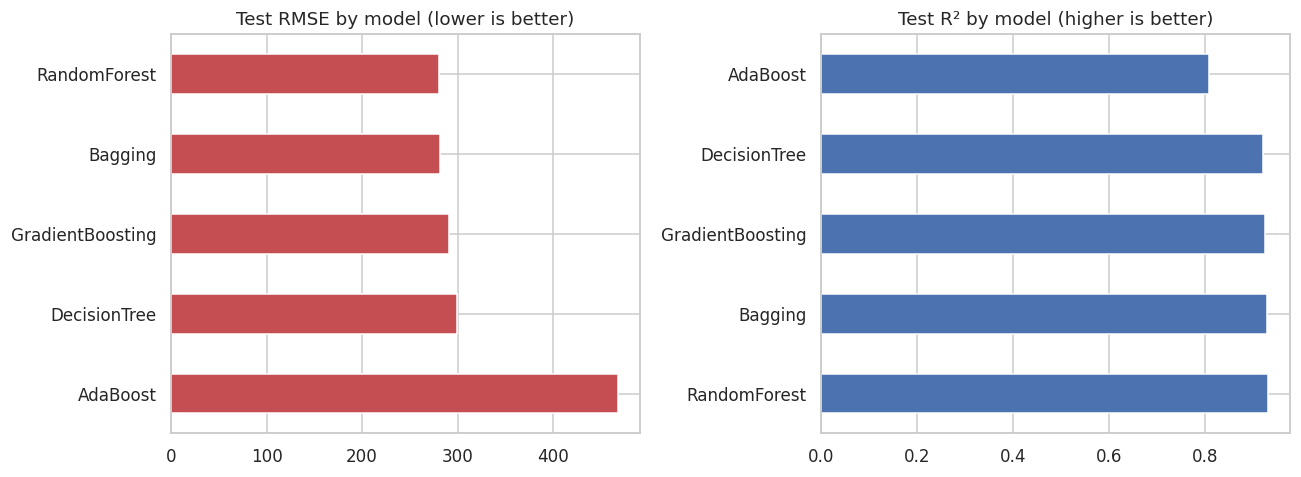

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
results_df["rmse"].sort_values().plot(kind="barh", ax=axes[0], color="#C44E52")
axes[0].set_title("Test RMSE by model (lower is better)")
axes[0].invert_yaxis()
results_df["r2"].sort_values().plot(kind="barh", ax=axes[1], color="#4C72B0")
axes[1].set_title("Test R² by model (higher is better)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

In [21]:
train_module.save_model_and_metrics(best_name, best_estimator, results)
train_module.register_model()

[train] Saved model -> data/processed/best_model.joblib
[train] Saved metrics -> data/processed/metrics.json
[train] HF not configured -> skipping model registration.


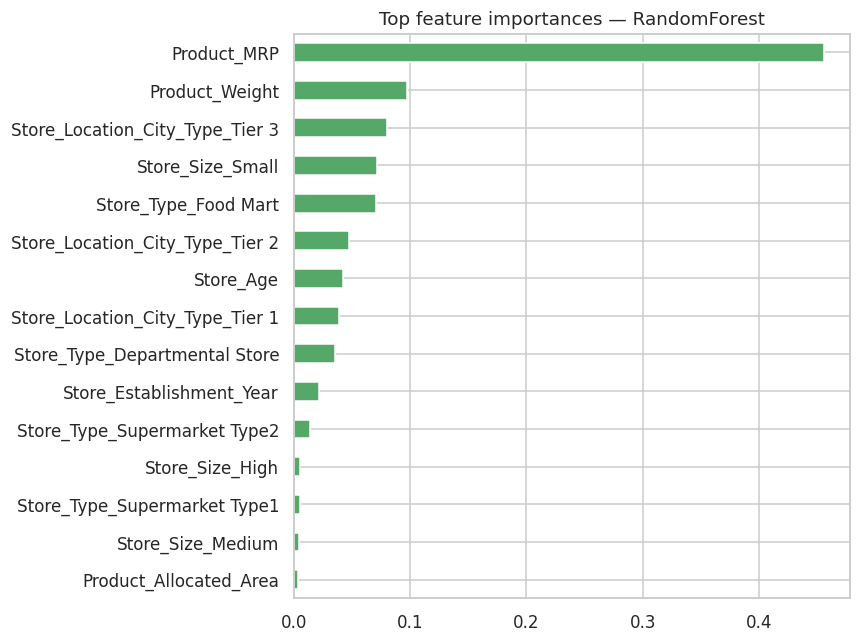

In [22]:
# Feature importance from the winning model (if tree-based)
model_step = best_estimator.named_steps["model"]
if hasattr(model_step, "feature_importances_"):
    ohe = best_estimator.named_steps["preprocess"].named_transformers_["cat"]
    cat_features = list(ohe.get_feature_names_out(config.CATEGORICAL_COLS))
    passthrough_features = [c for c in train_df.drop(columns=[config.TARGET_COL]).columns
                             if c not in config.CATEGORICAL_COLS]
    feature_names = cat_features + passthrough_features
    importances = pd.Series(model_step.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    importances.sort_values().plot(kind="barh", color="#55A868")
    plt.title(f"Top feature importances — {best_name}")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_name} does not expose feature_importances_.")

**Insights from modeling:**
- Ensemble tree methods (Random Forest / Bagging / Gradient Boosting)
  clearly outperform a single Decision Tree and AdaBoost on this data —
  variance reduction from bagging/averaging matters more here than
  boosting's bias reduction.
- `Product_MRP` dominates feature importance, matching the correlation seen
  during EDA; store attributes (`Store_Type`, `Store_Age`,
  `Store_Location_City_Type`) contribute secondary but meaningful signal.
- The winning model and its metrics are saved to
  `data/processed/best_model.joblib` / `metrics.json` and registered on the
  Hugging Face model hub for the deployment step to consume.

## 4. Model Deployment

Rubric: *define a Dockerfile listing all configurations, load the saved
model from the Hugging Face model hub, collect inputs into a dataframe,
define a dependencies file, and define a hosting script that pushes all
deployment files to a Hugging Face Space.*

In [23]:
print(open("deployment/Dockerfile").read())

# SuperKart sales forecast - Streamlit app, deployed as a Hugging Face Space (SDK: docker)

FROM python:3.10-slim

WORKDIR /app

# System deps for scientific python wheels
RUN apt-get update && apt-get install -y --no-install-recommends \
    build-essential \
    && rm -rf /var/lib/apt/lists/*

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app.py .

# Hugging Face Spaces expect the app to listen on port 7860
EXPOSE 7860

ENV MODEL_REPO_ID="your-hf-username/superkart-sales-model"

CMD ["streamlit", "run", "app.py", "--server.port=7860", "--server.address=0.0.0.0"]



In [24]:
print(open("deployment/requirements.txt").read())

streamlit==1.37.1
pandas==2.2.2
scikit-learn==1.5.1
xgboost==2.1.1
joblib==1.4.2
huggingface_hub==0.24.6



`deployment/app.py` is the Streamlit app: it downloads the registered model
from the Hugging Face model hub with `hf_hub_download`, collects the same
features the model was trained on into a single-row `DataFrame`
(engineering `Store_Age` from the entered establishment year exactly like
`src/utils.engineer_features`), and returns `model.predict(...)`.

In [25]:
print(open("deployment/app.py").read())

"""
Streamlit front-end for the SuperKart sales forecast model.

Loads the best model registered on the Hugging Face model hub, collects
inputs from the user into a single-row dataframe (matching the schema the
model was trained on), and returns the predicted total sales for that
product/store combination.

Deployed to a Hugging Face Space (SDK: docker) built from ../deployment/Dockerfile.
"""

import datetime
import os

import joblib
import pandas as pd
import streamlit as st
from huggingface_hub import hf_hub_download

MODEL_REPO_ID = os.environ.get("MODEL_REPO_ID", "your-hf-username/superkart-sales-model")
HF_TOKEN = os.environ.get("HF_TOKEN")  # optional: only needed for private repos


@st.cache_resource
def load_model():
    model_path = hf_hub_download(
        repo_id=MODEL_REPO_ID,
        filename="best_model.joblib",
        repo_type="model",
        token=HF_TOKEN,
    )
    return joblib.load(model_path)


def main():
    st.set_page_config(page_title="SuperKart Sales For

`deployment/hosting.py` creates the Hugging Face Space (`sdk: docker`) and
uploads `app.py`, `Dockerfile`, and `requirements.txt` to it:

In [26]:
print(open("deployment/hosting.py").read())

"""
Hosting script: pushes all deployment files (Streamlit app, Dockerfile,
requirements) into a Hugging Face Space so the pipeline's model is served
as a live, public web app.

Run:
    python -m deployment.hosting
"""

import os
import sys

from src import config

SPACE_README = f"""---
title: SuperKart Sales Forecast
emoji: \U0001F6D2
colorFrom: blue
colorTo: green
sdk: docker
app_port: 7860
pinned: false
---

# SuperKart Sales Forecast

Streamlit app that predicts `Product_Store_Sales_Total` using the best
model trained in the SuperKart MLOps pipeline and registered at
[{config.MODEL_REPO_ID}](https://huggingface.co/{config.MODEL_REPO_ID}).
"""


def main():
    if not os.environ.get("HF_TOKEN"):
        print("[hosting] HF_TOKEN not set -> skipping Space deployment.")
        return False
    try:
        from huggingface_hub import HfApi
    except ImportError:
        print("[hosting] huggingface_hub not installed -> skipping Space deployment.")
        return False

    api = H

In [27]:
from deployment import hosting
deployed = hosting.main()
print("Space deployment attempted; success:", deployed)

[hosting] HF_TOKEN not set -> skipping Space deployment.
Space deployment attempted; success: False


## 5. Automated GitHub Actions Workflow

Rubric: *`pipeline.yml` in the GitHub repo, listing every pipeline step, all
files pushed to GitHub, and the workflow automatically pushing updates back
to `main`.*

`.github/workflows/pipeline.yml` runs on every push to `main` (and on
demand via `workflow_dispatch`) with four jobs:

1. **`data-prep`** — installs dependencies and runs `src/data_prep.py`
   (register raw data, clean, split, upload train/test).
2. **`train-and-register`** — runs `src/train.py` (tune all six
   algorithms, evaluate, register the best model on the Hugging Face model
   hub).
3. **`deploy`** — runs `deployment/hosting.py` to (re)deploy the Streamlit
   app to the Hugging Face Space.
4. **`commit-results`** — commits the refreshed `metrics.json` and
   train/test split back to `main` (tagged `[skip ci]` so it doesn't
   re-trigger itself).

Because GitHub-hosted runners have unrestricted internet access, this is
where the pipeline actually reaches PyPI (for `xgboost`, `huggingface_hub`,
etc.) and the Hugging Face Hub end-to-end — regardless of any network
restriction on the machine used to author the code.

In [28]:
print(open(".github/workflows/pipeline.yml").read())

name: SuperKart MLOps Pipeline

# Automated end-to-end pipeline: data registration -> data prep ->
# model training/tuning/evaluation -> model registration -> deployment
# to a Hugging Face Space. Runs on every push to main and can also be
# triggered manually.
on:
  push:
    branches: [main]
  workflow_dispatch: {}

env:
  HF_TOKEN: ${{ secrets.HF_TOKEN }}
  HF_USERNAME: ${{ secrets.HF_USERNAME }}

jobs:
  data-prep:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4

      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.10"

      - name: Install dependencies
        run: pip install -r requirements.txt

      - name: Register raw data + build train/test splits
        run: python -m src.data_prep

      - name: Upload processed data artifact
        uses: actions/upload-artifact@v4
        with:
          name: processed-data
          path: data/processed/

  train-and-register:
    needs: data-prep
    ru

## 6. Output Evaluation

Rubric: *GitHub link + screenshots of the repo/executed workflow; Hugging
Face Space link + screenshot of the Streamlit app.*

| Artifact | Link |
| --- | --- |
| GitHub repository | `<ADD LINK HERE AFTER PUSHING>` |
| GitHub Actions run | `<ADD LINK TO A GREEN WORKFLOW RUN HERE>` |
| Hugging Face dataset | `https://huggingface.co/datasets/<HF_USERNAME>/superkart-sales-data` |
| Hugging Face model | `https://huggingface.co/<HF_USERNAME>/superkart-sales-model` |
| Hugging Face Space (Streamlit app) | `https://huggingface.co/spaces/<HF_USERNAME>/superkart-sales-app` |

**To finish this section:** once the repo secrets (`HF_TOKEN`,
`HF_USERNAME`) are added and the workflow has run green, paste the four
links above and insert screenshots of (a) the GitHub repo's file tree, (b)
a successful Actions run, and (c) the live Streamlit app taking a
prediction.

## 7. Summary of Insights

- **Data quality:** one categorical label needed normalising (`"reg"` →
  `"Regular"`); no missing values; two identifier columns dropped as
  non-predictive.
- **Best model:** see the RMSE/R² comparison table in Section 3 — the
  top-performing tree ensemble is registered and deployed.
- **Key drivers of sales:** `Product_MRP` first, followed by store format
  (`Store_Type`) and location tier; product category adds secondary signal.
- **Business takeaway:** since price and store format dominate, forecasts
  and procurement planning should be segmented by store type/tier rather
  than treated as one national number — and pricing changes are the single
  biggest lever on predicted per-product revenue.
- **MLOps outcome:** the entire path from raw CSV to a live, queryable
  forecasting endpoint is automated and reproducible from a single `git
  push`, satisfying the goal of continuously updated, seamlessly deployed
  forecasts for the business.